# AO1 - Clase 2
## Limpieza, Transformación y Análisis Exploratorio de Datos
Alumno: Nicolás Santillán

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder

In [2]:
df = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Juan", "María", "Pedro", "Ana", "Luis"],
    "Edad": [32, -28, 40, 35, 50],
    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
    "Salario": [50000, 60000, None, 55000, 200000],
    "Categoria": ["Junior", "Senior", "Senior", "Junior", "Manager"],
    "Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
})

df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,-28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


In [3]:
print(df.info())
print(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               5 non-null      int64  
 1   Nombre           5 non-null      object 
 2   Edad             5 non-null      int64  
 3   Nivel_Educativo  5 non-null      object 
 4   Salario          4 non-null      float64
 5   Categoria        5 non-null      object 
 6   Estado           5 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 412.0+ bytes
None
              ID Nombre      Edad Nivel_Educativo        Salario Categoria  \
count   5.000000      5   5.00000               5       4.000000         5   
unique       NaN      5       NaN               3            NaN         3   
top          NaN   Juan       NaN      Licenciado            NaN    Junior   
freq         NaN      1       NaN               2            NaN         2   
mean    3.000000    NaN 

## 1. Identificación de tipos de datos

- ID: numérico entero. Identificador, no se usa para modelar.
- Nombre: categórico nominal. Sirve como referencia, no aporta valor predictivo.
- Edad: numérico. Debe revisarse por posibles errores o valores atípicos.
- Nivel_Educativo: categórico ordinal. Tiene un orden lógico.
- Salario: numérico. Puede tener faltantes y outliers.
- Categoria: categórico ordinal. Puede ordenarse según jerarquía laboral.
- Estado: categórico nominal/binario. Debe unificarse por inconsistencias.

In [4]:
print("Valores faltantes:")
print(df.isnull().sum())

print("\nEdades negativas:")
print(df[df["Edad"] < 0])

print("\nValores duplicados:")
print(df.duplicated().sum())

print("\nValores únicos de Estado:")
print(df["Estado"].unique())

Valores faltantes:
ID                 0
Nombre             0
Edad               0
Nivel_Educativo    0
Salario            1
Categoria          0
Estado             0
dtype: int64

Edades negativas:
   ID Nombre  Edad Nivel_Educativo  Salario Categoria  Estado
1   2  María   -28       Ingeniero  60000.0    Senior  ACTIVO

Valores duplicados:
0

Valores únicos de Estado:
['Activo' 'ACTIVO' 'Inactivo']


In [5]:
df["Edad"] = df["Edad"].abs()
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


In [6]:
df["Salario"] = df["Salario"].fillna(df["Salario"].median())
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


In [7]:
df["Estado"] = df["Estado"].str.capitalize()
print(df["Estado"].unique())

['Activo' 'Inactivo']


In [8]:
Q1 = df["Salario"].quantile(0.25)
Q3 = df["Salario"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

outliers = df[(df["Salario"] < limite_inferior) | (df["Salario"] > limite_superior)]
print("\nOutliers detectados:")
print(outliers)

Q1: 55000.0
Q3: 60000.0
IQR: 5000.0
Límite inferior: 47500.0
Límite superior: 67500.0

Outliers detectados:
   ID Nombre  Edad Nivel_Educativo   Salario Categoria    Estado
4   5   Luis    50       Doctorado  200000.0   Manager  Inactivo


In [9]:
df = df[(df["Salario"] >= limite_inferior) & (df["Salario"] <= limite_superior)]
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,Activo
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo


In [10]:
encoder_nivel = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df.loc[:, "Nivel_Cod"] = encoder_nivel.fit_transform(df[["Nivel_Educativo"]])
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0


In [11]:
encoder_categoria = OrdinalEncoder(categories=[["Junior", "Senior", "Manager"]])
df.loc[:, "Categoria_Cod"] = encoder_categoria.fit_transform(df[["Categoria"]])
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod,Categoria_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0


In [12]:
df.loc[:, "Estado_Cod"] = df["Estado"].map({"Activo": 1, "Inactivo": 0})
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1


In [13]:
scaler = MinMaxScaler()
df.loc[:, "Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1,0.00
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1,1.00
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0,0.75
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1,0.50


In [14]:
df.loc[:, "Anios_Hasta_Jubilacion"] = 65 - df["Edad"]
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado,Anios_Hasta_Jubilacion
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1,0.00,33
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1,1.00,37
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0,0.75,25
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1,0.50,30


In [15]:
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado,Anios_Hasta_Jubilacion
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1,0.00,33
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1,1.00,37
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0,0.75,25
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1,0.50,30


In [16]:
print(df.describe())

             ID       Edad       Salario  Nivel_Cod  Categoria_Cod  \
count  4.000000   4.000000      4.000000   4.000000        4.00000   
mean   2.500000  33.750000  55625.000000   0.750000        0.50000   
std    1.290994   5.057997   4269.562819   0.957427        0.57735   
min    1.000000  28.000000  50000.000000   0.000000        0.00000   
25%    1.750000  31.000000  53750.000000   0.000000        0.00000   
50%    2.500000  33.500000  56250.000000   0.500000        0.50000   
75%    3.250000  36.250000  58125.000000   1.250000        1.00000   
max    4.000000  40.000000  60000.000000   2.000000        1.00000   

       Estado_Cod  Salario_Normalizado  Anios_Hasta_Jubilacion  
count        4.00             4.000000                4.000000  
mean         0.75             0.562500               31.250000  
std          0.50             0.426956                5.057997  
min          0.00             0.000000               25.000000  
25%          0.75             0.375000      

In [17]:
print(df[["Edad", "Salario", "Nivel_Cod", "Categoria_Cod", "Estado_Cod", "Anios_Hasta_Jubilacion"]].corr())

                            Edad   Salario  Nivel_Cod  Categoria_Cod  \
Edad                    1.000000 -0.067530   0.464620       0.057073   
Salario                -0.067530  1.000000   0.662541       0.845154   
Nivel_Cod               0.464620  0.662541   1.000000       0.904534   
Categoria_Cod           0.057073  0.845154   0.904534       1.000000   
Estado_Cod             -0.823778 -0.292770  -0.870388      -0.577350   
Anios_Hasta_Jubilacion -1.000000  0.067530  -0.464620      -0.057073   

                        Estado_Cod  Anios_Hasta_Jubilacion  
Edad                     -0.823778               -1.000000  
Salario                  -0.292770                0.067530  
Nivel_Cod                -0.870388               -0.464620  
Categoria_Cod            -0.577350               -0.057073  
Estado_Cod                1.000000                0.823778  
Anios_Hasta_Jubilacion    0.823778                1.000000  


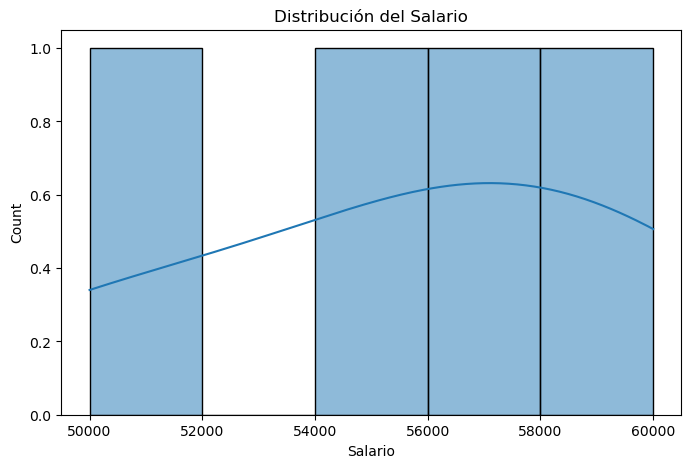

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salario"], bins=5, kde=True)
plt.title("Distribución del Salario")
plt.show()

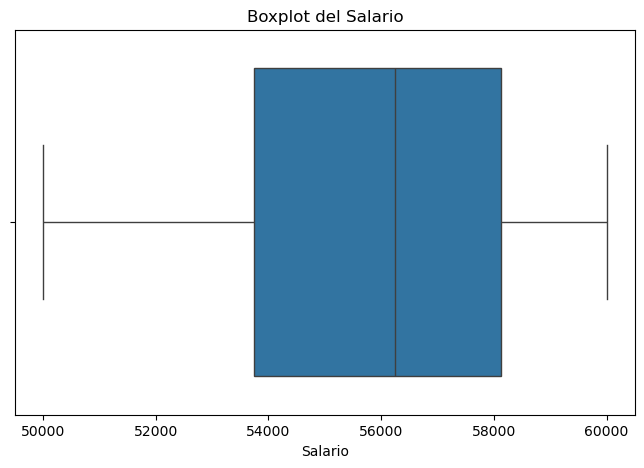

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Salario"])
plt.title("Boxplot del Salario")
plt.show()

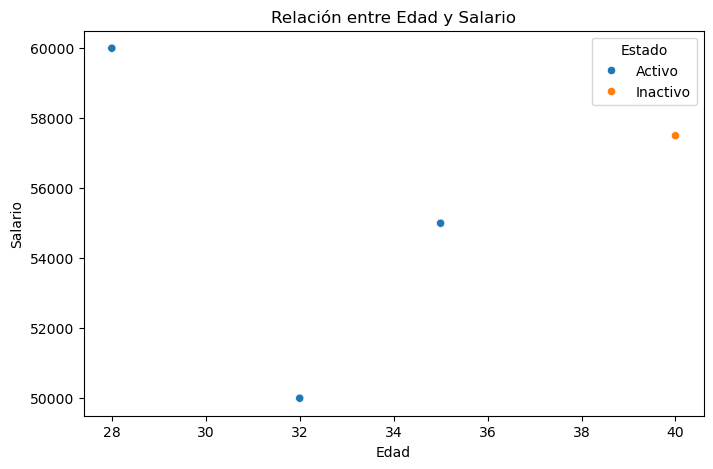

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Edad", y="Salario", hue="Estado")
plt.title("Relación entre Edad y Salario")
plt.show()

## Interpretación de resultados

- Se detectó un valor faltante en la columna Salario, que fue reemplazado por la mediana.
- Se corrigió una edad negativa convirtiéndola a valor absoluto.
- Se unificaron valores inconsistentes en la columna Estado.
- Se detectó un outlier en Salario mediante el método IQR y se eliminó.
- Los gráficos permiten observar la distribución del salario y la relación entre edad y salario.

## Uso de LLM

### Prompt 1
"Tengo un dataset con sueldos y edades, ¿cómo puedo detectar y eliminar outliers en Python?"

### Síntesis de la respuesta
El LLM sugirió usar el método IQR para detectar valores atípicos, calculando Q1, Q3 y el rango intercuartílico. También explicó que los valores por fuera de los límites pueden eliminarse o revisarse según el contexto.

### Validación propia
Elegí usar IQR porque es un método simple, claro y adecuado para datasets pequeños como este. Además, coincide con la estrategia sugerida en la clase.

### Prompt 2
"¿Qué gráficos básicos puedo usar para explorar un dataset con edad, salario y estado laboral?"

### Síntesis de la respuesta
El LLM sugirió usar histogramas para ver distribuciones, boxplots para detectar outliers y gráficos de dispersión para analizar relaciones entre variables numéricas.

### Validación propia
Apliqué esas recomendaciones en el notebook porque ayudan a visualizar la estructura del dataset y facilitan la interpretación antes de modelar.

## Conclusión

En esta actividad se identificaron los tipos de datos del dataset y se aplicaron técnicas de limpieza, transformación y análisis exploratorio. Se corrigieron errores, se imputaron faltantes, se trataron inconsistencias y outliers, y se transformaron variables categóricas a numéricas. Finalmente, las visualizaciones permitieron comprender mejor la distribución de los datos y sus relaciones.